In [1]:
# Cell 1. Kaggle P100 compatible setup

# P100 = Pascal / sm_60
# Kaggle 기본 PyTorch가 sm_60을 지원하지 않는 경우가 있으므로 CUDA 12.6 빌드로 재설치
!pip uninstall -y torch torchvision torchaudio -q
!pip install -q torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu126

!pip install -q h5py onnx onnxruntime opencv-python

import os
import sys
import glob
import shlex
import shutil
import subprocess
from pathlib import Path

REPO = "https://github.com/InHyunseo/AUE4040-team-project.git"
REPO_DIR = Path("/kaggle/working/AUE4040-team-project")
TRAIN_DIR = REPO_DIR / "final_project" / "training"

if not REPO_DIR.exists():
    print("Cloning repository...")
    !git clone -q $REPO $REPO_DIR
else:
    print("Repository already exists:", REPO_DIR)

%cd /kaggle/working/AUE4040-team-project/final_project/training

import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("vram:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
    print("capability:", torch.cuda.get_device_capability(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 215.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 216.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 231.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 64.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 79.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 117.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 175.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 132.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 109.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 122.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 125.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 98.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import h5py
import glob
import shutil
from pathlib import Path

print("Kaggle input folders:")
!ls -lah /kaggle/input

print("\nFound h5 files:")
!find /kaggle/input -name "*.h5" | head -50

INPUT_H5 = sorted(glob.glob("/kaggle/input/**/*.h5", recursive=True))
print(f"\n/kaggle/input에서 찾은 h5 개수: {len(INPUT_H5)}")

if len(INPUT_H5) == 0:
    raise FileNotFoundError(
        "h5 파일을 찾지 못함. Kaggle Notebook 우측 Add data에서 h5 파일이 들어있는 Dataset을 먼저 연결해야 함."
    )

# True: /kaggle/working으로 복사해서 학습
# False: /kaggle/input에서 직접 읽기
# 데이터가 4GB 정도면 False부터 시도해도 됨.
# 학습 중 GPU 사용률이 낮으면 True로 변경.
USE_WORKING_COPY = False

WORK_H5_DIR = Path("/kaggle/working/labels_all")
WORK_H5_DIR.mkdir(parents=True, exist_ok=True)

if USE_WORKING_COPY:
    CACHES = []

    for i, src in enumerate(INPUT_H5):
        src = Path(src)

        # 서로 다른 폴더의 같은 파일명 충돌 방지
        dst = WORK_H5_DIR / f"{i:03d}_{src.name}"

        if not dst.exists():
            print("copy:", src, "->", dst)
            shutil.copy2(src, dst)

        CACHES.append(str(dst))
else:
    CACHES = INPUT_H5

print(f"\n학습에 사용할 h5 개수: {len(CACHES)}")

for c in CACHES:
    try:
        with h5py.File(c, "r") as f:
            print(f"{c} → samples: {f['lane'].shape[0]} | keys: {list(f.keys())}")
    except Exception as e:
        print(f"{c} 파일 오류: {e}")

Kaggle input folders:
total 12K
drwxr-xr-x 3 root root 4.0K Jun 11 11:52 .
drwxr-xr-x 8 root root 4.0K Jun 11 11:52 ..
drwxr-xr-x 3 root root 4.0K Jun 11 11:52 datasets

Found h5 files:
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache15.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache11.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache16.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache7.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache12.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache8.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache14.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache2.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache5.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache3.h5
/kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache1.h5
/kaggle/input/dat

total samples: 28545


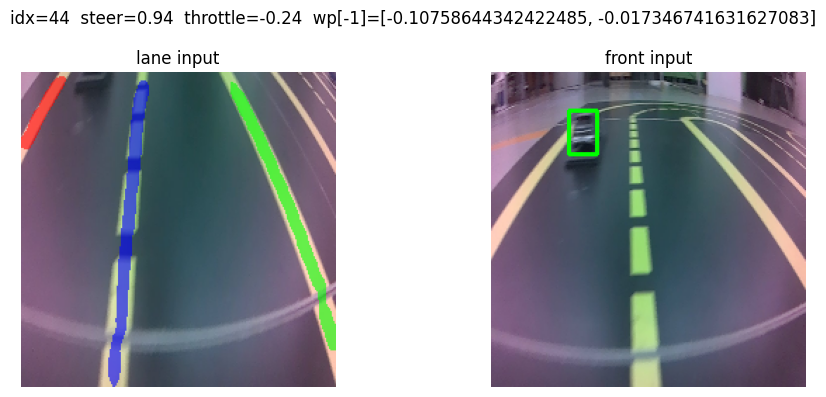

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from dataset import E2EDataset, IMAGENET_MEAN, IMAGENET_STD

ds = E2EDataset(CACHES, augment=False)
print("total samples:", len(ds))

def denorm(t):
    # (3,H,W) normalized tensor -> RGB uint8
    x = t.numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(x * 255, 0, 255).astype(np.uint8)

idx = min(44, len(ds) - 1)

lane_t, front_t, steer, thr, wp = ds[idx]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(denorm(lane_t))
ax[0].set_title("lane input")
ax[0].axis("off")

ax[1].imshow(denorm(front_t))
ax[1].set_title("front input")
ax[1].axis("off")

plt.suptitle(
    f"idx={idx}  steer={steer:.2f}  throttle={thr:.2f}  wp[-1]={wp[-1].tolist()}"
)
plt.tight_layout()
plt.show()

In [4]:
import os
import sys
import shlex

CKPT = "/kaggle/working/e2e_best.pt"
VIZ_DIR = "/kaggle/working/train_viz"

# 이어 학습하려면 아래처럼 설정
# RESUME = CKPT
RESUME = ""

EPOCHS = 60
BATCH = 32
LR = 3e-4
VAL_FRAC = 0.15
WORKERS = 4
PATIENCE = 10

USE_VIZ = True
VIZ_EVERY = 5

cache_args = " ".join(f"--cache {shlex.quote(c)}" for c in CACHES)
resume_arg = f"--resume {shlex.quote(RESUME)}" if RESUME else ""

viz_arg = ""
if USE_VIZ:
    viz_arg = f"--viz_dir {shlex.quote(VIZ_DIR)} --viz_every {VIZ_EVERY}"

cmd = (
    f"{sys.executable} train_e2e.py {cache_args} "
    f"--out {shlex.quote(CKPT)} "
    f"{viz_arg} "
    f"{resume_arg} "
    f"--epochs {EPOCHS} "
    f"--batch {BATCH} "
    f"--lr {LR} "
    f"--val_frac {VAL_FRAC} "
    f"--workers {WORKERS} "
    f"--patience {PATIENCE} "
    f"--device cuda"
)

print(cmd)
!{cmd}

/usr/bin/python3 train_e2e.py --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache1.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache10.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache11.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache12.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache13.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache14.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache15.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache16.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache2.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache3.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache4.h5 --cache /kaggle/input/datasets/hyunseoin/labels-all/labels_all/labels_cache5.h5 --c

186 viz panels in /kaggle/working/train_viz; showing last epoch (6)


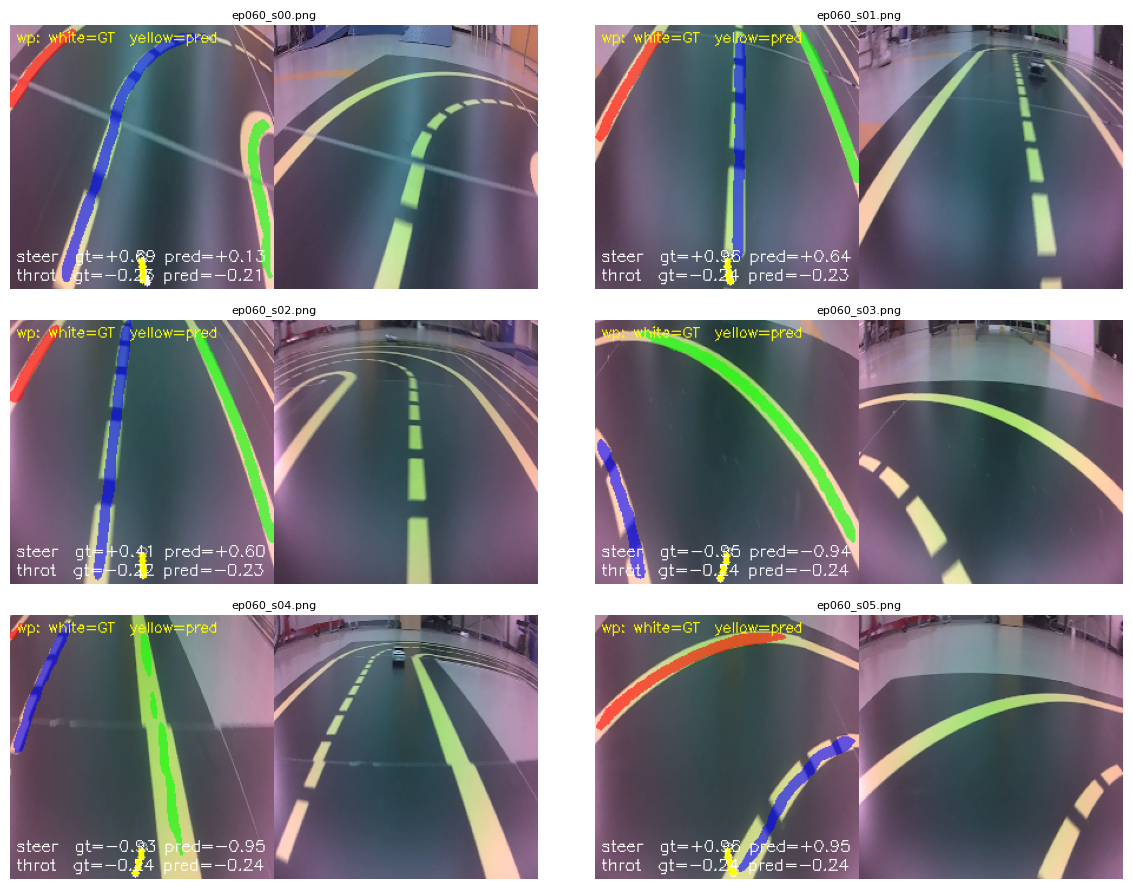

In [5]:
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

pngs = sorted(glob.glob(f"{VIZ_DIR}/*.png"))

last = []
if pngs:
    last_ep = max(os.path.basename(p).split("_")[0] for p in pngs)
    last = [p for p in pngs if os.path.basename(p).startswith(last_ep + "_")]

print(f"{len(pngs)} viz panels in {VIZ_DIR}; showing last epoch ({len(last)})")

n = min(6, len(last))

if n:
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(12, 3 * rows))
    axes = np.ravel(axes)

    for ax, p in zip(axes, last[:n]):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(os.path.basename(p), fontsize=8)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("no viz panels found")

In [6]:
import sys

ONNX = "/kaggle/working/e2e.onnx"

!{sys.executable} export_onnx.py --ckpt {CKPT} --out {ONNX} --check

print("saved checkpoint:", CKPT)
print("saved onnx:", ONNX)

loaded ckpt: epoch=57 val_total=0.0299
exported -> /kaggle/working/e2e.onnx
  steer     max|Δ| = 2.12e-07
  throttle  max|Δ| = 2.98e-08
  waypoints max|Δ| = 1.86e-08
check done (expect ~1e-5 or less)
next (Jetson only): trtexec --onnx=/kaggle/working/e2e.onnx --fp16 --saveEngine=e2e.engine
saved checkpoint: /kaggle/working/e2e_best.pt
saved onnx: /kaggle/working/e2e.onnx
